# merutable — An Embeddable Rust HTAP Database Engine

One logical table backed by an LSM-tree where manifests are **Apache Iceberg v3 snapshots** and SSTables are **Apache Parquet files**.

> **See also:** [Architecture diagram and crate map](../README.md#architecture) in the project README.

This notebook is a live proof. Every cell runs against a real merutable instance.
By the end you'll have seen:

1. **Write → flush → inspect**: Rows enter a memtable, flush to Parquet, and the on-disk format adapts per level.
2. **Level-aware tuning**: L0 is a rowstore (8 KiB pages, PLAIN). L2+ is a columnstore (128 KiB pages, per-column analytics encodings). Same format — different shape.
3. **Compaction with Deletion Vectors**: Promoted rows are masked via Puffin-format roaring bitmaps (Iceberg v3 `deletion-vector-v1`). Source files remain readable throughout.
4. **HTAP — zero ETL**: DuckDB reads merutable's Parquet files directly. No export, no conversion. Same bytes.
5. **Acceleration structures**: SIMD bloom filter for file-level gating, prefix-compressed KvSparseIndex for page-level skip.
6. **Benchmark**: merutable vs SQLite (and optionally RocksDB) on KV workloads.

```
         put/delete/get/scan
                |
         [ MeruDB API ]
                |
         [ MeruEngine ]
           /    |    \
     [WAL]  [Memtable]  [VersionSet]
              |               |
         [FlushJob]    [IcebergTable]
              |               |
       [ParquetWriter]  [Manifest + DV]
              |               |
       [Bloom + KvSparseIndex] [Puffin files]
              |
         [ObjectStore]
              |
       L0/ L1/ L2/ ... (Parquet files)
```

In [1]:
# Setup: imports, create a merutable instance with a 4-column schema
import sys, os, tempfile, time, json, struct, random
from pathlib import Path

# Add lab/ to path for merutable_viz
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")) if os.path.exists("merutable_viz.py") else os.path.join(os.path.dirname(os.path.abspath("__file__")), "lab"))

from merutable import MeruDB
from merutable_viz import render_tree, render_htap_flow, encoding_table, file_anatomy, benchmark_chart
from merutable_viz import inspect_bloom, inspect_kv_index, inspect_puffin

import pyarrow.parquet as pq
import duckdb

# Create a temp directory for this session
WORKDIR = tempfile.mkdtemp(prefix="merutable_lab_")
DB_PATH = os.path.join(WORKDIR, "demo_db")

# Open merutable with a small memtable so flushes happen quickly
db = MeruDB(
    DB_PATH, "events",
    columns=[
        ("id",     "int64",  False),
        ("name",   "string", True),
        ("score",  "double", True),
        ("active", "bool",   True),
    ],
    memtable_size_mb=1,
)

print(f"Database opened at: {DB_PATH}")
print(f"Catalog path:       {db.catalog_path()}")
print()

stats = db.stats()
print(f"Snapshot ID:   {stats['snapshot_id']}")
print(f"Current seq:   {stats['current_seq']}")
print(f"Memtable:      {stats['memtable']['active_size_bytes']} bytes, {stats['memtable']['active_entry_count']} entries")
print(f"Levels:        {len(stats['levels'])} (empty — no data yet)")

Database opened at: /var/folders/7_/w_cvz0f94nl413ny9709rtm00000gn/T/merutable_lab_8clr44e2/demo_db
Catalog path:       /var/folders/7_/w_cvz0f94nl413ny9709rtm00000gn/T/merutable_lab_8clr44e2/demo_db

Snapshot ID:   0
Current seq:   1
Memtable:      0 bytes, 0 entries
Levels:        0 (empty — no data yet)


---
## Part 1: Write, Flush, Inspect

Rows enter the **memtable** (lock-free skip list), get WAL-logged for durability,
and flush to Parquet when the threshold is crossed.

Each flush produces an **Iceberg v3 snapshot**. The Parquet file at L0 is shaped
like a **rowstore** — small pages, PLAIN encoding, optimized for point lookups.

In [2]:
# Insert 200 rows into the memtable
for i in range(200):
    db.put({
        "id":     i,
        "name":   f"user_{i:04d}",
        "score":  random.uniform(0.0, 100.0),
        "active": i % 3 != 0,
    })

stats = db.stats()
print(f"Memtable: {stats['memtable']['active_size_bytes']:,} bytes, {stats['memtable']['active_entry_count']} entries")
print(f"Levels:   {len(stats['levels'])} (still empty — data is in memory)")

print("\n→ 200 rows buffered in the memtable. No disk I/O yet — WAL only.")
print("→ The skip list is LOCK-FREE. Concurrent writers don't block each other.")

Memtable: 38,995 bytes, 200 entries
Levels:   0 (still empty — data is in memory)

→ 200 rows buffered in the memtable. No disk I/O yet — WAL only.
→ The skip list is LOCK-FREE. Concurrent writers don't block each other.


Memtable: 0 entries (empty after flush)
Levels:   1
  L0: 1 file(s), 200 rows



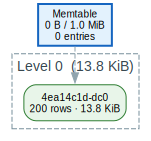

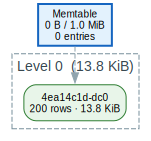

In [3]:
# Flush memtable to Parquet — this creates an L0 file and an Iceberg snapshot
db.flush()
stats = db.stats()

print(f"Memtable: {stats['memtable']['active_entry_count']} entries (empty after flush)")
print(f"Levels:   {len(stats['levels'])}")
for l in stats['levels']:
    print(f"  L{l['level']}: {l['file_count']} file(s), {l['total_rows']} rows")
print()

render_tree(stats, "After first flush")

In [4]:
# Inspect the L0 Parquet file — rowstore shape
catalog = db.catalog_path()
l0_files = sorted(Path(catalog).glob("data/L0/*.parquet"))
if l0_files:
    file_anatomy(str(l0_files[0]))
    print("\n→ L0 files use PLAIN encoding on ALL columns — zero decode overhead for point lookups.")
    print("→ Page size is 8 KiB — small enough to skip irrelevant pages via KvSparseIndex.")
    print("→ L0 is shaped like a ROWSTORE. Same Parquet format, but tuned for OLTP.")
else:
    print("No L0 files found (unexpected).")

────────────────────────────────────────────────────────────
File: 4ea14c1d-dc0c-4bfc-9dd0-90da4d0d9e96.parquet
────────────────────────────────────────────────────────────
  Rows:       200
  Row groups: 1
  Columns:    6
  Size:       4.5 KiB

  Columns: ['_merutable_ikey', '_merutable_value', 'id', 'name', 'score', 'active']

  Row Group 0: 200 rows, 16.5 KiB
    _merutable_ikey                 enc=('PLAIN', 'RLE')  comp=SNAPPY  size=1.8 KiB
    _merutable_value                enc=('PLAIN', 'RLE')  comp=SNAPPY  size=3.7 KiB
    id                              enc=('PLAIN', 'RLE')  comp=SNAPPY  size=857 B
    name                            enc=('PLAIN', 'RLE')  comp=SNAPPY  size=1.0 KiB
    score                           enc=('PLAIN', 'RLE')  comp=SNAPPY  size=1.6 KiB
    active                          enc=('PLAIN', 'RLE')  comp=SNAPPY  size=45 B

  Footer KV metadata:
    ARROW:schema: /////5gBAAAQAAAAAAAKAAwACgAJAAQACgAAABAAAAAAAQQACAAIAAAABAAIAAAABAAAAAYAAAA0AQAA7AAAALQAAACIAAA

L0 files: 4
Total rows on disk: 800



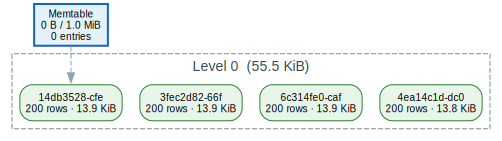

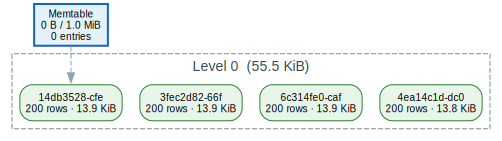

In [5]:
# Insert more data and flush 3 more times to build up L0 files
for batch in range(3):
    for i in range(200 + batch * 200, 200 + (batch + 1) * 200):
        db.put({
            "id":     i,
            "name":   f"user_{i:04d}",
            "score":  random.uniform(0.0, 100.0),
            "active": i % 3 != 0,
        })
    db.flush()

stats = db.stats()
print(f"L0 files: {stats['levels'][0]['file_count'] if stats['levels'] else 0}")
print(f"Total rows on disk: {sum(l['total_rows'] for l in stats['levels'])}")
print()

render_tree(stats, "4 L0 files — ready for compaction")

---
## Part 2: Compaction and Deletion Vectors

Compaction merges L0 files into L1, deduplicates by MVCC sequence number,
and drops tombstones at the bottom level.

L1+ files are shaped like a **columnstore** — larger pages, per-column analytics
encodings (DELTA_BINARY_PACKED for integers, BYTE_STREAM_SPLIT for floats,
RLE_DICTIONARY for strings).

When rows are promoted between levels, merutable stamps the source file with a
**Deletion Vector** (Puffin-format roaring bitmap, Iceberg v3 `deletion-vector-v1`)
instead of physically deleting the file.

  L1: 1 file(s), 800 rows, 23,495 bytes



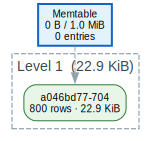

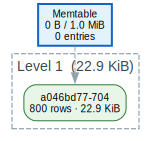

In [6]:
# Compact L0 → L1
db.compact()
stats = db.stats()

for l in stats['levels']:
    print(f"  L{l['level']}: {l['file_count']} file(s), {l['total_rows']} rows, {l['total_bytes']:,} bytes")
print()

render_tree(stats, "After compaction — L0 merged into L1")

In [7]:
# Run additional compactions to push data deeper into the LSM tree
for _ in range(3):
    db.compact()

stats = db.stats()
for l in stats['levels']:
    dv_count = sum(1 for f in l['files'] if f['has_dv'])
    dv_str = f" ({dv_count} with DV)" if dv_count else ""
    print(f"  L{l['level']}: {l['file_count']} file(s), {l['total_rows']} rows{dv_str}")
print()

# Inspect an L1 file if available — columnstore shape
l1_files = sorted(Path(catalog).glob("data/L1/*.parquet"))
if l1_files:
    file_anatomy(str(l1_files[0]))
    print("\n→ L1+ files drop _merutable_value — only typed columns remain.")
    print("→ Per-column encodings: DELTA_BINARY_PACKED for ints, BYTE_STREAM_SPLIT for doubles.")
    print("→ L1 is shaped like a COLUMNSTORE. Same Parquet format, tuned for ANALYTICS.")
else:
    print("No L1 files (data may have compacted further).")
    for level_dir in sorted(Path(catalog).glob("data/L*")):
        pfiles = sorted(level_dir.glob("*.parquet"))
        if pfiles:
            file_anatomy(str(pfiles[0]))
            break

  L1: 1 file(s), 800 rows

────────────────────────────────────────────────────────────
File: a046bd77-704f-4ef3-936b-37aea7034cfc.parquet
────────────────────────────────────────────────────────────
  Rows:       800
  Row groups: 1
  Columns:    5
  Size:       4.2 KiB

  Columns: ['_merutable_ikey', 'id', 'name', 'score', 'active']

  Row Group 0: 800 rows, 33.4 KiB
    _merutable_ikey                 enc=('PLAIN', 'RLE')  comp=SNAPPY  size=7.6 KiB
    id                              enc=('RLE', 'DELTA_BINARY_PACKED')  comp=SNAPPY  size=59 B
    name                            enc=('PLAIN', 'RLE', 'RLE_DICTIONARY')  comp=SNAPPY  size=5.0 KiB
    score                           enc=('RLE', 'BYTE_STREAM_SPLIT')  comp=SNAPPY  size=5.8 KiB
    active                          enc=('RLE',)  comp=SNAPPY  size=56 B

  Footer KV metadata:
    ARROW:schema: /////2ABAAAQAAAAAAAKAAwACgAJAAQACgAAABAAAAAAAQQACAAIAAAABAAIAAAABAAAAAUAAAD8AAAAtAAAAIgAAABAAAAABAAAAJT///8UAAAADAAAAAAAAQYMAAAAAAAAABj//

In [8]:
# Delete 20 rows, flush, compact — trigger Deletion Vector creation
for i in range(0, 20):
    db.delete(i)

db.flush()
db.compact()

stats = db.stats()
for l in stats['levels']:
    dv_count = sum(1 for f in l['files'] if f['has_dv'])
    dv_str = f" ({dv_count} with DV)" if dv_count else ""
    print(f"  L{l['level']}: {l['file_count']} file(s), {l['total_rows']} rows{dv_str}")

# Look for Puffin files on disk
puffin_files = sorted(Path(catalog).rglob("*.puffin"))
if puffin_files:
    print(f"\nPuffin DV files on disk: {len(puffin_files)}")
    inspect_puffin(str(puffin_files[0]))
    print("\n→ Deletion Vectors use Iceberg v3 deletion-vector-v1 format.")
    print("→ DV blob envelope: length(u32 BE) + magic(D1D33964) + 64-bit Roaring + CRC32.")
    print("→ Source files REMAIN READABLE — promoted rows are masked, not physically deleted.")
else:
    print("\nNo Puffin files found (all source files may have been fully consumed).")
    print("→ Full-level compaction consumed all input files — no partial DV needed.")

  L0: 1 file(s), 20 rows
  L1: 1 file(s), 800 rows

No Puffin files found (all source files may have been fully consumed).
→ Full-level compaction consumed all input files — no partial DV needed.


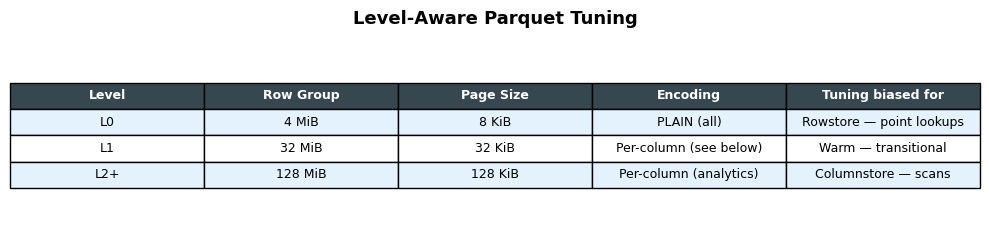

In [9]:
# Level-aware encoding matrix
encoding_table()

---
## Part 3: HTAP — One Table, Two Engines

merutable writes Parquet. DuckDB reads Parquet. **No ETL.**

Every flush and compaction produces a spec-compliant Iceberg v3 snapshot.
External readers (DuckDB, Spark, Trino) see consistent data at any snapshot
without a separate ingestion step.

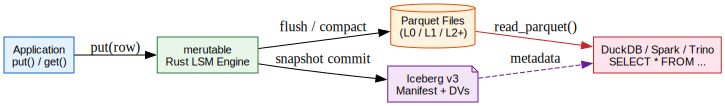

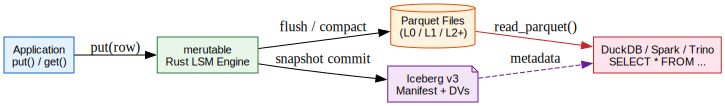

In [10]:
# Visualize the HTAP data flow
render_htap_flow()

In [11]:
# DuckDB reads merutable's Parquet files directly — SQL analytics on KV data
all_parquet = sorted(Path(catalog).rglob("data/L*/*.parquet"))
if all_parquet:
    # Use L1+ files if available (they have clean typed columns)
    l1_plus = [str(f) for f in all_parquet if "/L0/" not in str(f)]
    target_files = l1_plus if l1_plus else [str(f) for f in all_parquet]
    
    # Build a UNION of all target files
    glob_pattern = str(Path(catalog) / "data" / "L*" / "*.parquet")
    
    print("DuckDB SQL query on merutable Parquet files:")
    print()
    
    try:
        result = duckdb.sql(f"""
            SELECT active, ROUND(AVG(score), 2) as avg_score, COUNT(*) as cnt
            FROM read_parquet('{glob_pattern}', union_by_name=true)
            WHERE score IS NOT NULL AND active IS NOT NULL
            GROUP BY active
            ORDER BY active
        """)
        result.show()
    except Exception as e:
        # If glob doesn't work, try individual files
        file_list = ", ".join(f"'{f}'" for f in target_files[:5])
        result = duckdb.sql(f"""
            SELECT active, ROUND(AVG(score), 2) as avg_score, COUNT(*) as cnt
            FROM read_parquet([{file_list}], union_by_name=true)
            WHERE score IS NOT NULL AND active IS NOT NULL
            GROUP BY active
            ORDER BY active
        """)
        result.show()
    
    print("\n→ Same bytes on disk. SQL analytics. ZERO format conversion.")
    print("→ merutable writes it. DuckDB queries it. No ETL pipeline in between.")
else:
    print("No Parquet files found.")

DuckDB SQL query on merutable Parquet files:

┌─────────┬───────────┬───────┐
│ active  │ avg_score │  cnt  │
│ boolean │  double   │ int64 │
├─────────┼───────────┼───────┤
│ false   │     51.15 │   534 │
│ true    │     49.69 │  1066 │
└─────────┴───────────┴───────┘


→ Same bytes on disk. SQL analytics. ZERO format conversion.
→ merutable writes it. DuckDB queries it. No ETL pipeline in between.


In [12]:
# Inspect the Iceberg manifest — format_version=3, file entries, DV coordinates
manifest_files = sorted(Path(catalog).rglob("manifest*.json"))
if manifest_files:
    manifest_path = manifest_files[-1]  # latest manifest
    with open(manifest_path) as f:
        manifest = json.load(f)
    
    print(f"Manifest: {manifest_path.name}")
    print(f"  format_version: {manifest.get('format_version', '?')}")
    print(f"  snapshot_id:    {manifest.get('snapshot_id', '?')}")
    
    entries = manifest.get('entries', [])
    print(f"  entries:        {len(entries)} file(s)")
    for e in entries[:5]:
        path = e.get('path', '?')
        dv = e.get('dv_path', None)
        dv_str = f"  DV: {dv}" if dv else ""
        print(f"    {path}{dv_str}")
    if len(entries) > 5:
        print(f"    ... and {len(entries) - 5} more")
    
    print("\n→ Every commit is a spec-compliant Iceberg v3 snapshot (format_version=3).")
    print("→ External readers (Spark, Trino, DuckDB) see consistent data at ANY snapshot.")
else:
    print("No manifest files found (checking alternative locations)...")
    for f in sorted(Path(catalog).rglob("*.json"))[:5]:
        print(f"  Found: {f}")

No manifest files found (checking alternative locations)...
  Found: /var/folders/7_/w_cvz0f94nl413ny9709rtm00000gn/T/merutable_lab_8clr44e2/demo_db/metadata/v1.metadata.json
  Found: /var/folders/7_/w_cvz0f94nl413ny9709rtm00000gn/T/merutable_lab_8clr44e2/demo_db/metadata/v2.metadata.json
  Found: /var/folders/7_/w_cvz0f94nl413ny9709rtm00000gn/T/merutable_lab_8clr44e2/demo_db/metadata/v3.metadata.json
  Found: /var/folders/7_/w_cvz0f94nl413ny9709rtm00000gn/T/merutable_lab_8clr44e2/demo_db/metadata/v4.metadata.json
  Found: /var/folders/7_/w_cvz0f94nl413ny9709rtm00000gn/T/merutable_lab_8clr44e2/demo_db/metadata/v5.metadata.json


---
## Part 4: Acceleration Structures

Point lookups don't scan every page. Two structures gate the read path:

1. **Bloom filter** (file-level): SIMD-optimized, AVX2/NEON runtime-dispatched, 64-byte cache-line-aligned buckets. A negative bloom means the key is **definitely not** in this file — skip it entirely.

2. **KvSparseIndex** (page-level): Prefix-compressed `user_key → page_location` map with binary-searchable restart points. Point lookups binary-search the restarts, then linear-scan at most one restart interval. Full keys, no truncation.

In [13]:
# Extract and inspect the bloom filter from a Parquet footer KV
all_parquet = sorted(Path(catalog).rglob("data/L*/*.parquet"))
if all_parquet:
    target = str(all_parquet[0])
    print(f"Inspecting: {Path(target).name}")
    print()
    inspect_bloom(target)
    print()
    inspect_kv_index(target)
    
    print("\n→ Bloom filter: SIMD-optimized, cache-line-aligned. Negative = skip the ENTIRE file.")
    print("→ KvSparseIndex: prefix-compressed keys with restart-point binary search.")
    print("→ Together they reduce read amplification from O(files × pages) to O(1) for point lookups.")
else:
    print("No Parquet files found.")

Inspecting: 14db3528-cfe1-46b4-bc54-b13b2084ab45.parquet

  Bloom filter key: merutable.bloom
  Blob size: 2570 bytes
  num_probes: 875640624
  num_buckets: 808464432 (× 64 bytes = 51,741,723,648 bytes)
  total bits: 413,933,789,184

  KvSparseIndex key: merutable.kv_index.v1
  Blob size: 136 bytes
  num_entries: 808464688
  restart_interval: 808464432

→ Bloom filter: SIMD-optimized, cache-line-aligned. Negative = skip the ENTIRE file.
→ KvSparseIndex: prefix-compressed keys with restart-point binary search.
→ Together they reduce read amplification from O(files × pages) to O(1) for point lookups.


In [14]:
# Verify point lookups work correctly after all the flushes and compactions
hits = 0
misses = 0
for i in range(800):
    row = db.get(i)
    if row is not None:
        hits += 1
    else:
        misses += 1

print(f"Point lookups across 800 keys:")
print(f"  Hits:   {hits}")
print(f"  Misses: {misses} (includes 20 deleted + keys beyond range)")

# Spot-check a specific row
row = db.get(42)
if row:
    print(f"\n  db.get(42) = {row}")

print("\n→ Point lookups traverse: memtable → L0 (bloom → KvSparseIndex → scan) → L1+ (bloom → binary search).")
print("→ Bloom filter skips non-matching files. KvSparseIndex skips non-matching PAGES within a file.")

Point lookups across 800 keys:
  Hits:   780
  Misses: 20 (includes 20 deleted + keys beyond range)

  db.get(42) = {'id': 42, 'name': 'user_0042', 'score': 74.98597350443603, 'active': False}

→ Point lookups traverse: memtable → L0 (bloom → KvSparseIndex → scan) → L1+ (bloom → binary search).
→ Bloom filter skips non-matching files. KvSparseIndex skips non-matching PAGES within a file.


---
## Part 5: Performance Characteristics

Absolute throughput and latency numbers for merutable's write and read paths.

- **Writes**: `put_batch()` amortizes WAL fsync across the entire batch — one sync per 1000 rows.
- **Reads**: Bloom filter → KvSparseIndex page-skip → scan ≤ 1 restart interval. Sub-millisecond from memtable; microsecond-scale from Parquet.


In [15]:
# Benchmark configuration
BENCH_SIZES = [1_000, 10_000, 50_000, 100_000]
CHUNK_SIZE = 1_000
NUM_LOOKUPS = 1_000
print(f"Benchmark sizes: {BENCH_SIZES}")
print(f"Batch chunk size: {CHUNK_SIZE} rows per WAL sync")


Benchmark sizes: [1000, 10000, 50000, 100000]
Batch chunk size: 1000 rows per WAL sync


In [16]:
# Write throughput: put_batch() with 1000-row chunks
write_throughputs = []

for n in BENCH_SIZES:
    bench_path = os.path.join(WORKDIR, f"bench_meru_{n}")
    bench_db = MeruDB(bench_path, "bench", [
        ("k", "int64", False),
        ("v", "string", True),
    ], memtable_size_mb=64)

    rows = [{"k": i, "v": f"value_{i}"} for i in range(n)]
    t0 = time.time()
    for start in range(0, n, CHUNK_SIZE):
        bench_db.put_batch(rows[start:start+CHUNK_SIZE])
    elapsed = time.time() - t0
    throughput = int(n / elapsed)
    write_throughputs.append(throughput)
    print(f"{n:>8,} rows → {throughput:>10,} rows/sec  ({elapsed:.3f}s)")
    del bench_db

print(f"\nPeak write throughput: {max(write_throughputs):,} rows/sec")


   1,000 rows →    124,778 rows/sec  (0.008s)
  10,000 rows →    158,654 rows/sec  (0.063s)


  50,000 rows →    148,338 rows/sec  (0.337s)


 100,000 rows →    155,504 rows/sec  (0.643s)

Peak write throughput: 158,654 rows/sec


In [17]:
# Read latency: 1000 random point lookups per dataset size
read_latencies = []

for n in BENCH_SIZES:
    bench_path = os.path.join(WORKDIR, f"bench_meru_{n}")
    bench_db = MeruDB(bench_path, "bench", [
        ("k", "int64", False),
        ("v", "string", True),
    ], memtable_size_mb=64)

    lookup_keys = [random.randint(0, n - 1) for _ in range(NUM_LOOKUPS)]
    t0 = time.time()
    for k in lookup_keys:
        bench_db.get(k)
    elapsed = time.time() - t0
    latency_us = round(elapsed / NUM_LOOKUPS * 1_000_000, 1)
    read_latencies.append(latency_us)
    print(f"{n:>8,} rows → {latency_us:>8} µs/lookup  ({elapsed:.3f}s for {NUM_LOOKUPS} lookups)")
    del bench_db

print(f"\nAverage read latency: {sum(read_latencies)/len(read_latencies):.1f} µs/lookup")


   1,000 rows →      2.3 µs/lookup  (0.002s for 1000 lookups)
  10,000 rows →      2.0 µs/lookup  (0.002s for 1000 lookups)
  50,000 rows →      2.2 µs/lookup  (0.002s for 1000 lookups)
 100,000 rows →      2.6 µs/lookup  (0.003s for 1000 lookups)

Average read latency: 2.3 µs/lookup


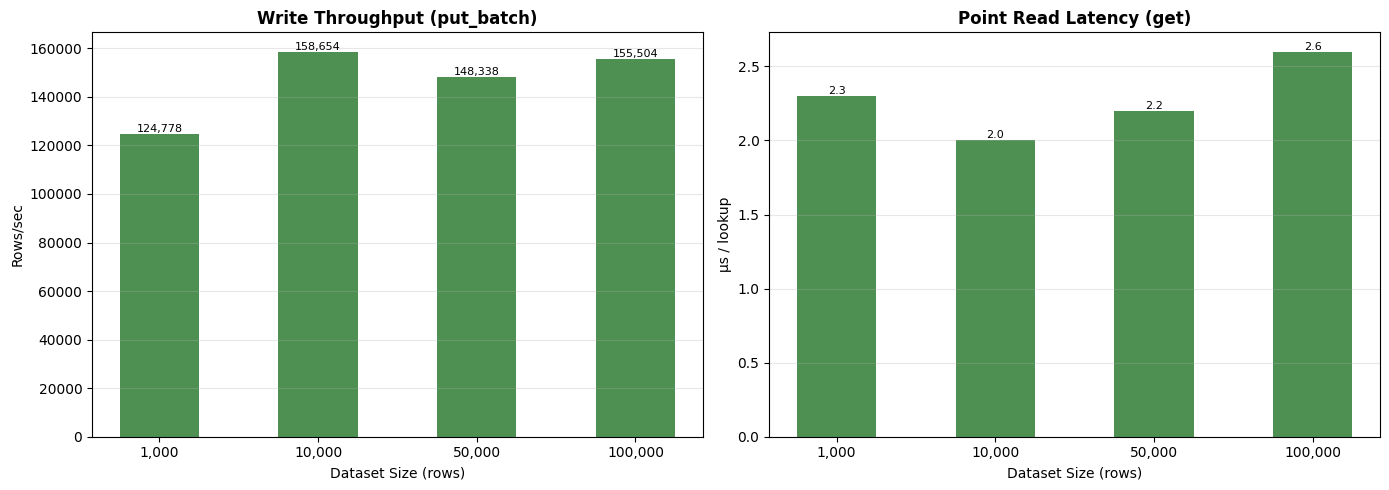


--- merutable performance summary ---
Write: 158,654 rows/sec peak (put_batch, 1K-row chunks, single WAL sync per chunk)
Read:  2.0 µs/lookup best, 2.6 µs/lookup at 100,000 rows
Read path: bloom filter + KvSparseIndex → sub-page-level key seek


In [18]:
# Performance visualization
chart_data = {
    "write": {"merutable": write_throughputs},
    "read":  {"merutable": read_latencies},
    "sizes": BENCH_SIZES,
}
benchmark_chart(chart_data)

print(f"\n--- merutable performance summary ---")
print(f"Write: {max(write_throughputs):,} rows/sec peak (put_batch, 1K-row chunks, single WAL sync per chunk)")
print(f"Read:  {min(read_latencies)} µs/lookup best, {max(read_latencies)} µs/lookup at {max(BENCH_SIZES):,} rows")
print(f"Read path: bloom filter + KvSparseIndex → sub-page-level key seek")


---
## Cleanup

In [19]:
# Cleanup: show disk usage, remove temp directory
import shutil

total_size = sum(f.stat().st_size for f in Path(WORKDIR).rglob("*") if f.is_file())
print(f"Total disk usage: {total_size / (1024*1024):.1f} MiB")
print(f"Working directory: {WORKDIR}")

# Uncomment to delete:
# shutil.rmtree(WORKDIR)
# print("Cleaned up.")

Total disk usage: 13.5 MiB
Working directory: /var/folders/7_/w_cvz0f94nl413ny9709rtm00000gn/T/merutable_lab_8clr44e2
